In [1]:
import numpy as np
import torch
import jax
import jax.numpy as jnp
# mute this since it requires py3.8 and py3.10 env, not default py3.11
import tensorflow as tf
import iree.compiler
import iree.runtime
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#### Method 1: in-command line tooling to compile and execute
!iree-compile ../../build/.matmul.mlir.linalg \
    -o ../../build/.matmul.vmfb \
    --iree-hal-target-backends=cuda \
    --iree-hal-cuda-llvm-target-arch=sm_70
    
!nohup iree-run-module \
    --device=cuda \
    --module="../../build/.matmul.vmfb" \
    --function=matmul \
    --input="2x512x1024xf32=0.01" \
    --input="2x1024x512xf32=0.01" > ../../build/.output 2>&1

In [2]:
!cat ../operator-cases/matmul.mlir
!../../build/bin/ragdoll-opt \
    ../operator-cases/matmul.mlir \
    --pass-pipeline="builtin.module(func.func(tosa-to-linalg-named))" > ../../build/.matmul.mlir.linalg
    # --pass-pipeline="builtin.module(func.func(tosa-to-linalg-named, linalg-generalize-named-ops))" > ../../build/.matmul.mlir.linalg
!cat ../../build/.matmul.mlir.linalg

module {
  func.func @matmul(%arg0: tensor<8x512x1024xf32>, %arg1: tensor<8x1024x512xf32>) -> tensor<8x512x512xf32> {
    %0 = tosa.matmul %arg0, %arg1 : (tensor<8x512x1024xf32>, tensor<8x1024x512xf32>) -> tensor<8x512x512xf32>
    return %0 : tensor<8x512x512xf32>
  }
}
module {
  func.func @matmul(%arg0: tensor<8x512x1024xf32>, %arg1: tensor<8x1024x512xf32>) -> tensor<8x512x512xf32> {
    %cst = arith.constant 0.000000e+00 : f32
    %0 = tensor.empty() : tensor<8x512x512xf32>
    %1 = linalg.fill ins(%cst : f32) outs(%0 : tensor<8x512x512xf32>) -> tensor<8x512x512xf32>
    %2 = linalg.batch_matmul ins(%arg0, %arg1 : tensor<8x512x1024xf32>, tensor<8x1024x512xf32>) outs(%1 : tensor<8x512x512xf32>) -> tensor<8x512x512xf32>
    return %2 : tensor<8x512x512xf32>
  }
}



In [3]:
# compile baseline ragdoll matmul
!iree-compile ../../build/.matmul.mlir.linalg \
    -o ../../build/.matmul.vmfb \
    --iree-hal-target-backends=cuda \
    --iree-hal-cuda-llvm-target-arch=sm_70

In [4]:
!iree-compile --help | grep fuse

  --iree-flow-enable-fuse-padding-into-linalg-consumer-ops                   - Enable fusing tensor.pad ops into Linalg consumer ops.
  --iree-flow-enable-fuse-padding-into-linalg-producer-ops                   - Enable fusing tensor.pad ops into Linalg consumer ops.
  --iree-flow-fuse-multi-use                                                 - Fuse multi-use ops.
                                                                               fused    indicates fused conditional jumps


In [5]:
!iree-compile --help | grep transform

  --iree-codegen-llvmcpu-enable-transform-dialect-jit                        - enable the usage of the transform dialect JIT
  --iree-codegen-llvmcpu-transform-dialect-debug-payload-tag=<string>        - tag attribute value for the transform dialect interpreter payload root operation
  --iree-codegen-llvmcpu-transform-dialect-debug-transform-tag=<string>      - tag attribute value for the transform dialect transform op container
  --iree-codegen-llvmcpu-use-transform-dialect=<string>                      - MLIR file containing a transform dialect specification to apply
  --iree-codegen-llvmgpu-enable-transform-dialect-aligned-matmul             - activate the matmul tensorcore strategy for tile aligned shapes
  --iree-codegen-llvmgpu-enable-transform-dialect-batch-matmul-strategy      - activate the batch matmul strategy, additional configuration flags are shared with matmul
  --iree-codegen-llvmgpu-enable-transform-dialect-implicit-gemm-strategy     - activate the convolution implicit

In [15]:
# compile baseline ragdoll matmul
!nohup iree-compile ../../build/.matmul.mlir.linalg \
-o ../../build/.matmul.candidate1.vmfb \
--mlir-print-ir-after-all \
-mlir-print-ir-after-change \
--td-matmul-strategy-use-wmma \
--iree-codegen-llvmgpu-enable-transform-dialect-matmul-tensorcore-strategy \
--iree-codegen-llvmgpu-enable-transform-dialect-aligned-matmul \
--iree-flow-fuse-multi-use \
--iree-flow-enable-fuse-padding-into-linalg-consumer-ops   \
--iree-flow-enable-fuse-padding-into-linalg-producer-ops  \
--iree-hal-target-backends=cuda \
--iree-hal-cuda-llvm-target-arch=sm_70 > ../../build/dump.mlir 2>&1
    
    #--iree-codegen-llvmgpu-enable-transform-dialect-jit=false \
    #--iree-codegen-llvmgpu-use-transform-dialect=../operator-cases/mma_using_layout_analysis_codegen_spec.mlir \

In [7]:
def iree_compile(workload_ir, input_type):
    #binary = iree.compiler.tools.compile_str(
    #    module, input_type="tosa", target_backends=["llvm-cpu"]
    #)
    #binary = iree.compiler.tools.compile_file(
    #    workload_ir, input_type=input_type, target_backends=["cuda"]
    #)
    #CPU
    #config = iree.runtime.system_api.Config("local-task")
    #GPU
    config = iree.runtime.system_api.Config("cuda")
    vmi = iree.runtime.VmInstance()
    vmm = iree.runtime.VmModule.from_flatbuffer(vmi, binary)
    vmo = iree.runtime.load_vm_module(vmm, config)
    return vmo
def iree_load(workload_fb, input_type):
    #binary = iree.compiler.tools.compile_str(
    #    module, input_type="tosa", target_backends=["llvm-cpu"]
    #)
    #binary = iree.compiler.tools.compile_file(
    #    workload_ir, input_type=input_type, target_backends=["cuda"]
    #)
    #CPU
    #config = iree.runtime.system_api.Config("local-task")
    #GPU
    config = iree.runtime.system_api.Config("cuda")
    vmi = iree.runtime.VmInstance()
    with open(workload_fb, 'rb') as file:
      binary_data = file.read()
    vmm = iree.runtime.VmModule.from_flatbuffer(vmi, binary_data)
    print(vmm)
    vmo = iree.runtime.load_vm_module(vmm, config)
    print(vmo)
    return vmo
#base_iree_module = iree_compile(workload_ir="../../build/.matmul.mlir.linalg", input_type="tosa")
#candy1_iree_module = iree_compile(workload_ir="../../build/.matmul.candidate1.vmfb", input_type="tosa")
base_iree_module = iree_load(workload_fb="../../build/.matmul.vmfb", input_type="tosa")
candy1_iree_module = iree_load(workload_fb="../../build/.matmul.candidate1.vmfb", input_type="auto")

<VmModule module : [matmul, __init]>
<BoundModule <VmModule module : [matmul, __init]>>
<VmModule module : [matmul, __init]>
<BoundModule <VmModule module : [matmul, __init]>>


/tmp/ipykernel_1107119/755474888.py:30: UserWarning: Making copy of unaligned VmModule buffer. It is recommended to make this deterministic by calling `copy_buffer` to always make a copy or `mmap` to efficiently load from a file. This warning can be silenced by adding `warn_if_copy=False` to `from_buffer`
  vmm = iree.runtime.VmModule.from_flatbuffer(vmi, binary_data)


In [8]:
from functools import wraps
from time import perf_counter
from collections import namedtuple

TestResult = namedtuple("TestResult", ("res", "forward_timecost"))


TimerResult = namedtuple("TimerResult", ("result", "timecost"))

def timer(func):
    @wraps(func)
    def wrapper(*args, **kwargs):
        start = perf_counter()
        res = func(*args, **kwargs)
        end = perf_counter()
        return TimerResult(res, end - start)
    return wrapper

def torch_test(lhs, rhs):
    lhs, rhs = [torch.from_numpy(i) for i in [lhs, rhs]]
    lhs.requires_grad = True
    rhs.requires_grad = True
    
    @timer
    def forward():
        return torch.bmm(lhs, rhs)
    
    res, forward_timecost = forward()
    
    return TestResult(res, forward_timecost)
    
def base_iree_test(lhs, rhs):
    @timer
    def forward():
        return base_iree_module["matmul"](lhs, rhs)[0]
    
    res, timecost = forward()
    return TestResult(res, timecost)

def candy1_iree_test(lhs, rhs):
    @timer
    def forward():
        return candy1_iree_module["matmul"](lhs, rhs)[0]
    
    res, timecost = forward()
    return TestResult(res, timecost)

def test_all_ntimes(n):
    lhs_list = [np.random.randn(8, 512, 1024).astype(np.float32) for _ in range(n)]
    rhs_list = [np.random.randn(8, 1024, 512).astype(np.float32) for _ in range(n)]
    
    def test(func):
        test_results = []
        for lhs, rhs in zip(lhs_list, rhs_list):
            test_results.append(func(lhs, rhs))
        return test_results
    torch_result = test(torch_test)
    base_iree_result = test(base_iree_test)
    candy1 = test(candy1_iree_test)
    return torch_result, base_iree_result, candy1
    
names = ["torch 2.0.1", "ragdoll-base", "candy1"]
def get_forward_array(res):
    return np.array(list(map(lambda x : x.forward_timecost, res)))[2:]

In [9]:
results = test_all_ntimes(17)
forward_line = pd.DataFrame(dict(zip(names, [get_forward_array(res) for res in results])))
forward_bar = pd.DataFrame(dict(zip(names, [[np.mean(get_forward_array(res))] for res in results])))

In [10]:
plt.rcParams["figure.dpi"] = 300
plt.rcParams["figure.figsize"] = (3, 3)

Text(0.5, 0.98, 'Time Cost')

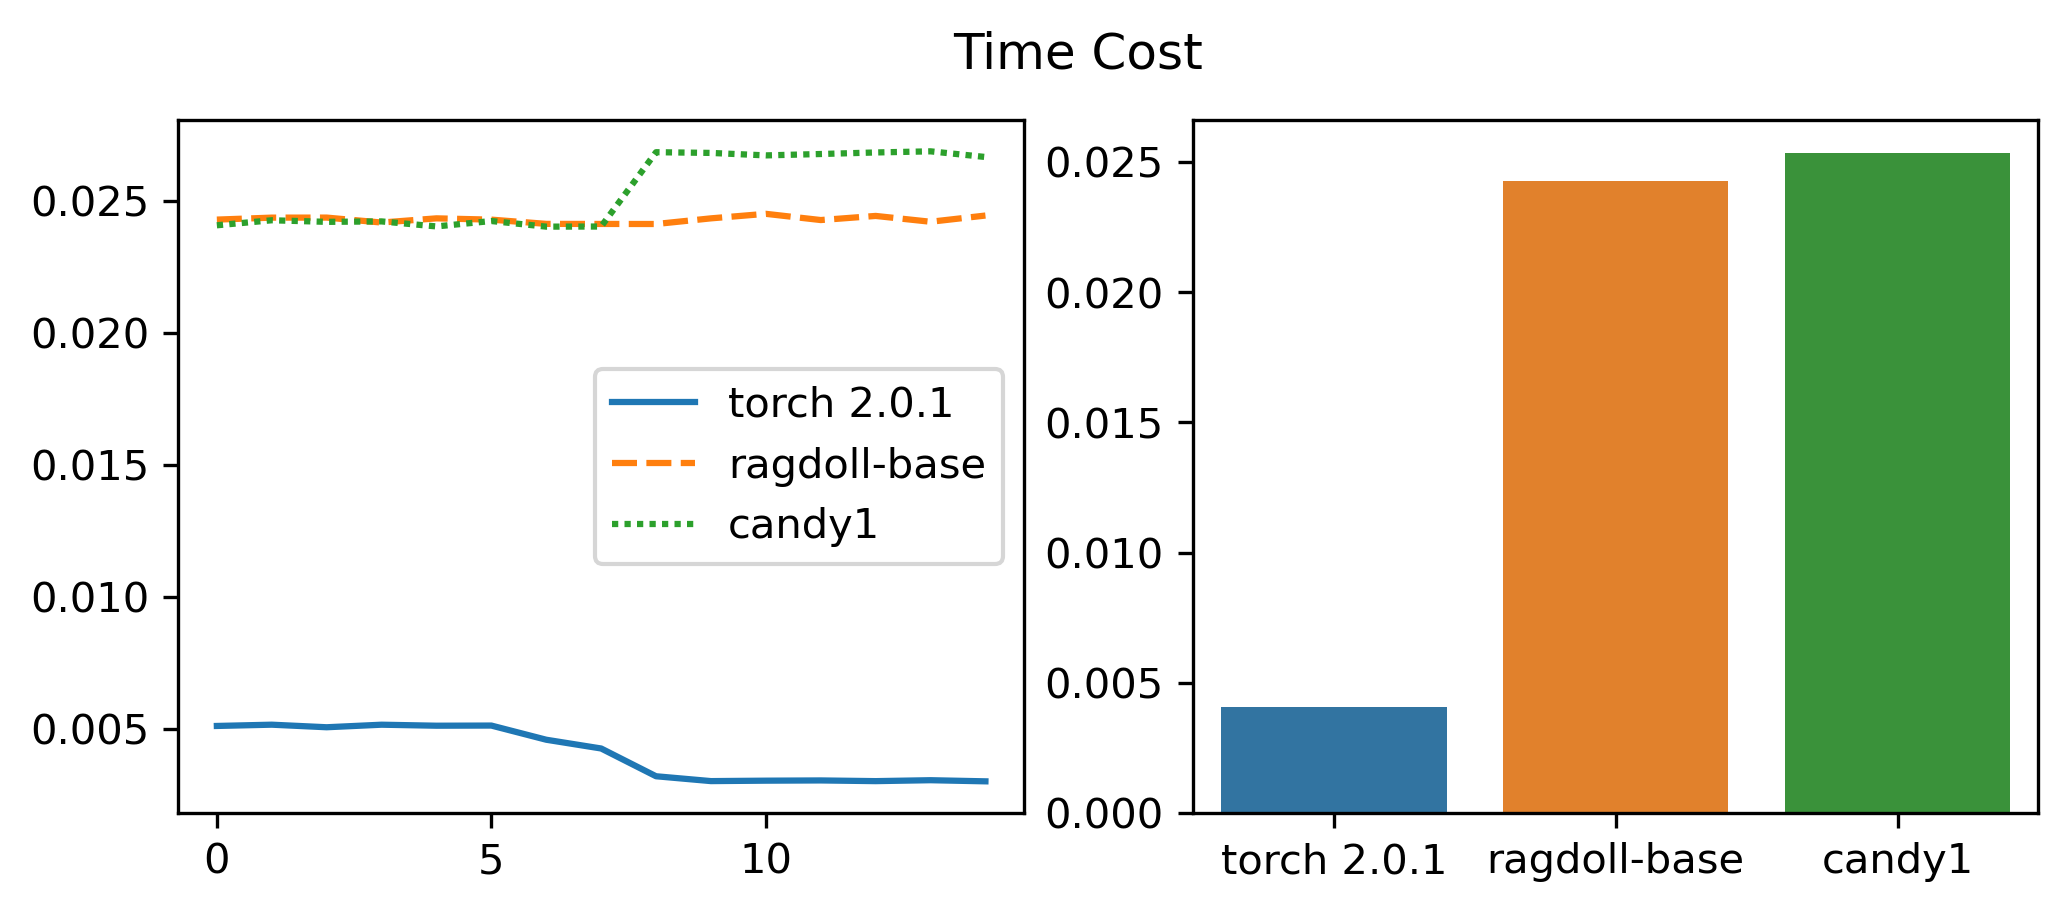

In [11]:
fig, (left, right) = plt.subplots(ncols=2, figsize=(8, 3))
sns.lineplot(forward_line, ax=left)
sns.barplot(forward_bar, ax=right)
plt.suptitle("Time Cost")